# Participant Analysis

In [14]:
# imports

import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data = "/Users/saachi/Desktop/Search-to-Change/processed_data/Reconciled_Data_Full.csv"
df = pd.read_csv(data)
df

,participant_no,week_no,query,info_type_sophie,info_type_ari,info_type_bowen,info_type_lexie,info_type_agreement,info_type_reconciliation,task_sophie,...,task_reconciliation,goal_sophie,goal_ari,goal_bowen,goal_lexie,goal_agreement,goal_reconciliation,final_type,final_task,final_goal
0,102,Week 1,foods to avoid while losing body fat,ideas/options,ideas/options,ideas/options,ideas/options,Y,NaN,barrier management,...,option seeking,plan,plan,plan,plan,Y,NaN,ideas/options,option seeking,plan
1,102,Week 1,foods to avoid while losing body fat,ideas/options,ideas/options,ideas/options,ideas/options,Y,NaN,barrier management,...,option seeking,plan,plan,plan,plan,Y,NaN,ideas/options,option seeking,plan
2,102,Week 1,foods to eat that help lose weight,ideas/options,ideas/options,ideas/options,ideas/options,Y,NaN,option seeking,...,NaN,plan,plan,plan,plan,Y,NaN,ideas/options,option seeking,plan
3,102,Week 1,foods to eat that help lose weight,ideas/options,ideas/options,ideas/options,ideas/options,Y,NaN,option seeking,...,NaN,plan,plan,plan,plan,Y,NaN,ideas/options,option seeking,plan
4,102,Week 1,vegan foods to eat that help lose weight,ideas/options,ideas/options,ideas/options,ideas/options,Y,NaN,option seeking,...,NaN,plan,plan,plan,plan,Y,NaN,ideas/options,option seeking,plan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2110,120,Week 4,winter temperature in cuverville island,na,factual,na,na,N,na,NaN,...,NaN,na,na,NaN,NaN,Y,NaN,na,na,na
2111,120,Week 4,winter temperature in cuverville island,na,factual,na,na,N,na,NaN,...,NaN,na,na,NaN,NaN,Y,NaN,na,na,na
2112,120,Week 4,physical activity and nutrition,factual,factual,factual,factual,Y,NaN,NaN,...,learn,plan,plan,NaN,NaN,Y,NaN,factual,learn,plan
2113,120,Week 4,which is the best hit training for weight loss,outcome expectancy,outcome expectancy,normative,normative,N,normative,NaN,...,NaN,plan,decision making,NaN,NaN,N,decision making,normative,evaluation,decision making


In [17]:
## Analysis 1 - Unique Queries per Participant

rows = []
for pid, grp in df.groupby("participant_no"):
    total  = len(grp)
    unique = grp["query"].nunique()
    weeks  = grp["week_no"].nunique()
    rows.append(dict(
        participant      = pid,
        total_queries    = total,
        unique_queries   = unique,
        repeat_rate      = round((total - unique) / total, 3),
        weeks_active     = weeks,
        queries_per_week = round(total / weeks, 1),
    ))

uq = pd.DataFrame(rows).set_index("participant")
uq


 

,total_queries,unique_queries,repeat_rate,weeks_active,queries_per_week
participant,,,,,
102,201,140,0.303,4,50.2
103,39,21,0.462,1,39.0
107,37,15,0.595,1,37.0
108,49,39,0.204,1,49.0
109,253,117,0.538,1,253.0
111,42,38,0.095,1,42.0
112,179,104,0.419,1,179.0
113,147,69,0.531,4,36.8
114,115,56,0.513,4,28.8


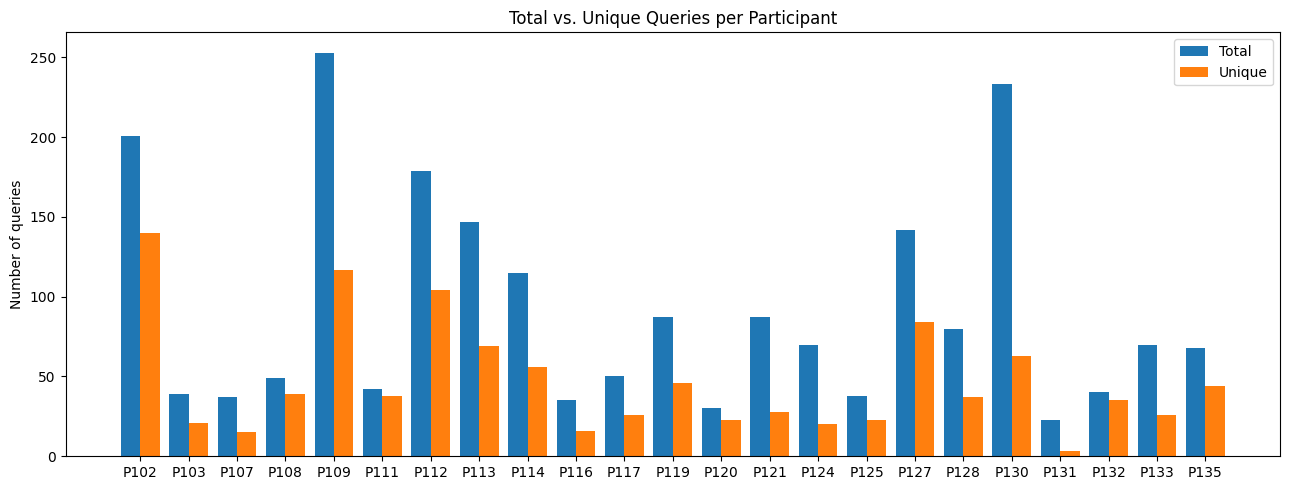

In [30]:
participants = sorted(df["participant_no"].unique())

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(participants))

ax.bar(x - 0.2, uq["total_queries"],  0.4, label="Total")
ax.bar(x + 0.2, uq["unique_queries"], 0.4, label="Unique")

ax.set_xticks(x)
ax.set_xticklabels([f"P{p}" for p in participants])
ax.set_ylabel("Number of queries")
ax.set_title("Total vs. Unique Queries per Participant")
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
def analysis_query_patterns(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    dims = {"final_type": "Info Type", "final_task": "Task", "final_goal": "Goal"}
    tables = {}
    for col, label in dims.items():
        ct = pd.crosstab(df["participant_no"], df[col], normalize="index") * 100
        ct.index.name = "participant"
        tables[label] = ct.round(1)
    return tables

patterns = analysis_query_patterns(df)

In [32]:
def proportion_profile(df: pd.DataFrame, col: str) -> pd.DataFrame:
    return (
        df[df[col] != "na"]
        .groupby(["participant_no", col])
        .size()
        .unstack(fill_value=0)
        .apply(lambda row: row / row.sum(), axis=1)
        .round(3)
    )

prof_type = proportion_profile(df, "final_type")
prof_task = proportion_profile(df, "final_task")
prof_goal = proportion_profile(df, "final_goal")

prof_type.columns = [f"type_{c}" for c in prof_type.columns]
prof_task.columns = [f"task_{c}" for c in prof_task.columns]
prof_goal.columns = [f"goal_{c}" for c in prof_goal.columns]

patterns_df = prof_type.join(prof_task).join(prof_goal)
patterns_df

,type_comparative,type_experiential,type_factual,type_how-to (procedural),type_how-to (psychological),type_ideas/options,type_mechanism,type_normative,type_outcome expectancy,type_utility,task_barrier management,task_evaluation,task_learn,task_logistics,task_option seeking,task_perform,goal_action,goal_decision making,goal_motivational reasoning,goal_plan
participant_no,,,,,,,,,,,,,,,,,,,,
102,0.035,0.030,0.250,0.015,0.005,0.220,0.035,0.185,0.150,0.075,0.005,0.225,0.390,0.095,0.200,0.085,0.110,0.270,0.060,0.560
103,0.000,0.000,0.128,0.103,0.000,0.769,0.000,0.000,0.000,0.000,0.000,0.000,0.205,0.000,0.795,0.000,0.000,0.000,0.000,1.000
107,0.057,0.000,0.000,0.000,0.000,0.371,0.000,0.429,0.143,0.000,0.057,0.486,0.171,0.000,0.286,0.000,0.000,0.486,0.143,0.371
108,0.000,0.056,0.167,0.056,0.000,0.278,0.000,0.028,0.056,0.361,0.000,0.000,0.250,0.194,0.250,0.306,0.429,0.057,0.171,0.343
109,0.000,0.005,0.161,0.080,0.025,0.407,0.030,0.065,0.186,0.040,0.031,0.046,0.538,0.046,0.338,0.000,0.050,0.179,0.104,0.667
111,0.048,0.000,0.048,0.000,0.000,0.452,0.071,0.071,0.262,0.048,0.000,0.143,0.452,0.000,0.357,0.048,0.095,0.357,0.238,0.310
112,0.000,0.000,0.159,0.114,0.000,0.636,0.017,0.017,0.017,0.040,0.068,0.017,0.222,0.034,0.642,0.017,0.078,0.134,0.034,0.754
113,0.000,0.007,0.156,0.054,0.000,0.721,0.000,0.048,0.014,0.000,0.020,0.027,0.272,0.061,0.619,0.000,0.109,0.327,0.000,0.565
114,0.000,0.018,0.125,0.339,0.000,0.473,0.000,0.027,0.000,0.018,0.116,0.036,0.348,0.018,0.482,0.000,0.018,0.071,0.107,0.804
